In [1]:
import pdfplumber
import math
import pandas
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from utils import encontrar_pdfs, crop_page

print("Imports carregados")

pdf_folder = "arquivos"

pdfs_encontrados = [f for f in encontrar_pdfs(pdf_folder) if f.lower().endswith(".pdf")]
print(f"Encontrados {len(pdfs_encontrados)} PDFs em {pdf_folder}")
for arquivo in pdfs_encontrados:
    print("-", arquivo)

idx = 0
arquivo = pdfs_encontrados[idx]
print(f"Analisando: {arquivo}")

pagina_idx = 38

def ajustar_linha(x_teorico, words, margem=15):
        """ Tenta mover o x_teorico para um espaço vazio próximo """
            
        conflitos = [w for w in words if abs(w['x0'] - x_teorico) < margem or abs(w['x1'] - x_teorico) < margem]
        
        if not conflitos:
            return x_teorico 
        
        esquerdas = [w['x1'] for w in conflitos if w['x1'] < x_teorico]
        direitas = [w['x0'] for w in conflitos if w['x0'] > x_teorico]
        
        novo_x = x_teorico
        if esquerdas and direitas:
            novo_x = (max(esquerdas) + min(direitas)) / 2
        elif esquerdas:
            novo_x = max(esquerdas) + 2 
        elif direitas:
            novo_x = min(direitas) - 2
            
        return novo_x

def filtrar_e_ajustar_h_lines(h_coords, words, margem_busca=5):
    """ 
    Remove linhas horizontais que estão no 'vazio' 
    e ajusta as que sobraram para os limites do texto.
    """
    h_validadas = []
    
    if not h_coords: return []
    h_validadas.append(h_coords[0])
    
    for y_teorico in h_coords[1:-1]:
        palavras_perto = [
            w for w in words 
            if abs(w['bottom'] - y_teorico) < margem_busca 
            or abs(w['top'] - y_teorico) < margem_busca
        ]
        
        if palavras_perto:
            tops_abaixo = [w['top'] for w in palavras_perto if w['top'] > y_teorico]
            bottoms_acima = [w['bottom'] for w in palavras_perto if w['bottom'] < y_teorico]
            
            if tops_abaixo and bottoms_acima:
                y_ajustado = (max(bottoms_acima) + min(tops_abaixo)) / 2
                h_validadas.append(y_ajustado)
            else:
                h_validadas.append(y_teorico)
                
    h_validadas.append(h_coords[-1])
    return sorted(list(set(h_validadas)))

Imports carregados
Encontrados 1 PDFs em arquivos
- arquivos/pastateste/Tormenta20-Edicao-Jogo-do-Ano-v1.3.pdf
Analisando: arquivos/pastateste/Tormenta20-Edicao-Jogo-do-Ano-v1.3.pdf


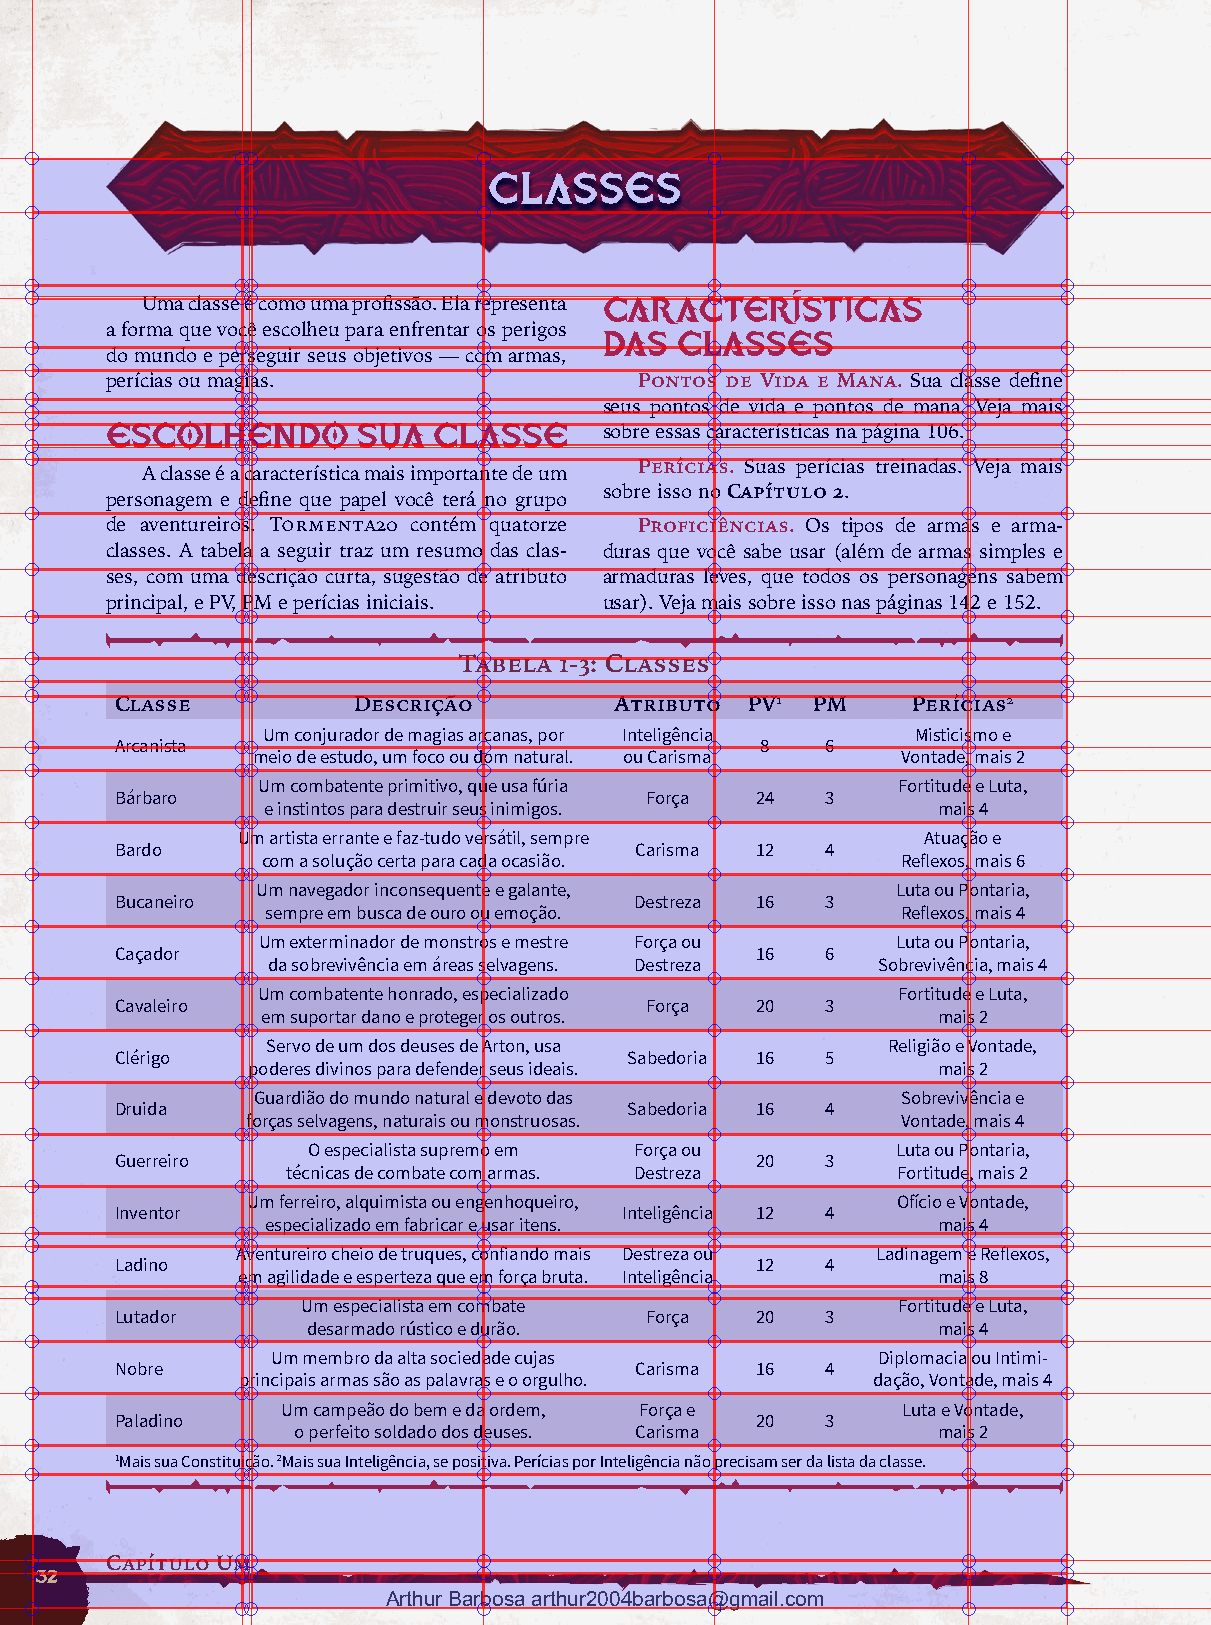

[[['', '', '', 'Classes', '', ''], ['', '', '', '', '', ''], ['', '', '', '', '', ''], ['Uma classe\na forma que vo', 'é\nc', 'como uma profissão. Ela r\nê escolheu para enfrentar o', 'Carac\nepresenta\ns perigos das Cl', 'terísticas\nasses', ''], ['do mundo e pe', 'r', 'seguir seus objetivos — co', 'm armas,', '', ''], ['perícias ou mag', 'i', 'as.', 'Pontos', 'de Vida e Mana. Sua cl', 'asse define'], ['', '', '', 'seus pontos', 'de vida e pontos de mana.', 'Veja mais'], ['', '', '', '', '', ''], ['Escolh', '', 'endo sua Cl', 'asse\nsobre essas c', 'aracterísticas na página 106.', ''], ['', '', '', '', '', ''], ['A classe é a\npersonagem e', 'c\nd', 'aracterística mais importa\nefine que papel você terá', 'Perícia\nnte de um\nsobre isso n\nno grupo', 's. Suas perícias treinadas.\no Capítulo 2.', 'Veja mais'], ['de aventureiro\nclasses. A tabel', 's\na', '. Tormenta20 contém\na seguir traz um resumo', 'quatorze Profici\ndas clas- duras que vo', 'ências. Os tipos de arma\ncê sabe usar (

In [17]:
from IPython.display import display
with pdfplumber.open(arquivo) as pdf:
   tables = []
   cropped = pdf.pages[37]

   v_coords = sorted(list(set([
      cropped.bbox[0],              
      cropped.bbox[2]               
   ])))

   table_settings_lines = {
      "horizontal_strategy": "text", 
      "snap_y_tolerance": 4,
      "join_tolerance": 5,
      "min_words_vertical": 1
   }

   finder = cropped.debug_tablefinder(table_settings=table_settings_lines)
   
   hlines_tops = [int(line['top']) for line in finder.edges]

   for i, line in enumerate(hlines_tops):
      if i > 0 and i < (len(hlines_tops)-1) and math.isclose((hlines_tops[i+1] - line), (line - hlines_tops[i-1]), rel_tol=0.2):
            hlines_tops.pop(i)

   words = cropped.extract_words()
   h_coords_limpas = filtrar_e_ajustar_h_lines(hlines_tops, words)

   table_settings_cols = {
      "vertical_strategy": "text", 
      "snap_y_tolerance": 4,
      "join_tolerance": 5,
      "min_words_vertical": 1
   }

   finder = cropped.debug_tablefinder(table_settings=table_settings_cols)
   
   vlines_tops = [int(line['x0']) for line in finder.edges]
   
   for i, line in enumerate(vlines_tops):
      if i > 0 and i < (len(vlines_tops)-1):
            if ((vlines_tops[i+1] - line) < 20):
               vlines_tops.pop(i)

   words = cropped.extract_text_lines()
   
   lines = [i for i in range(0, round(cropped.width), round(cropped.width/5))]
   linhas_ajustadas = [ajustar_linha(l, words, 100) for l in lines]
   linhas_ajustadas.append(cropped.extract_text_lines()[-2]['x1'])
   
   table_settings = {
      "vertical_strategy": "explicit",
      "explicit_vertical_lines": linhas_ajustadas,
      "horizontal_strategy": "explicit", 
      "explicit_horizontal_lines": h_coords_limpas,
      "snap_y_tolerance": 4,
      "join_tolerance": 5,
   }

   pag_tables = cropped.extract_tables(table_settings=table_settings)
   display(cropped.to_image(150).debug_tablefinder(table_settings=table_settings))
   print(pag_tables)